# Palettes, scientific colormaps and colormap builders

Behind the presets sits cleopatra's colour layer. This notebook shows three ways to get colour into a Digital-Earth map:

1. the **vendored palettes** (`cleopatra.styling.palettes`) - named colour sets you can turn into a colormap,
2. the **scientific colour maps**, reached the same way as any preset via `style=`,
3. the **colormap builders** (`make_diverging`, `perceptual_colormap`) for rolling your own - all applied to a map through the ordinary `cmap=` keyword.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from pyramids.dataset import Dataset
from digitalearth.scene import Map, grid
from cleopatra.styling.palettes import available_palettes, get_palette, make_diverging, perceptual_colormap

DATA = Path('../../../examples/data')   # notebook-relative path (docs/examples/presets -> repo root)
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
available_palettes()

['cams_aod_blue_red',
 'cams_aod_blue_yellow_red',
 'cams_aod_blue_yellow_red_brown',
 'cams_aod_oranges',
 'category12',
 'category20',
 'diverging_blue_red',
 'diverging_brown_teal',
 'diverging_purple_green',
 'flame_amber',
 'flame_white_hot',
 'haze_dust',
 'haze_organic_matter']

## A vendored palette as a colormap

`get_palette` returns a `Palette` (its `colors`, `kind` and `name`). Build a matplotlib colormap from its colours and hand it to `imshow(cmap=...)` like any other colormap.

diverging_blue_red | diverging | ('#2166ac', '#b2182b') ...


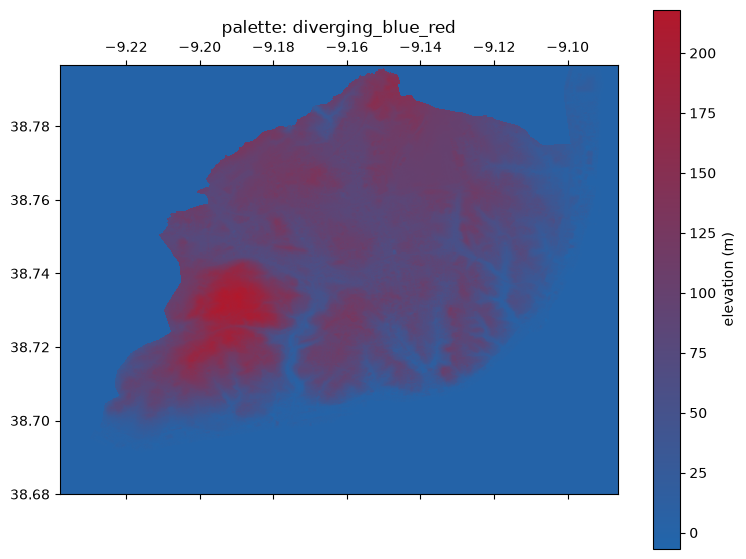

In [2]:
pal = get_palette('diverging_blue_red')
print(pal.name, '|', pal.kind, '|', pal.colors[:3], '...')
cmap = LinearSegmentedColormap.from_list(pal.name, list(pal.colors))
m = Map(crs=dem.epsg, figsize=(9, 7))
m.imshow(dem, cmap=cmap)
m.colorbar(label='elevation (m)'); m.set_title('palette: ' + pal.name); m.fig;

## Scientific colour maps via `style=`

The perceptually-uniform scientific colour maps (Crameri's batlow/broc/... family) are presets too - reach them exactly like the parameter presets, with `style=`.

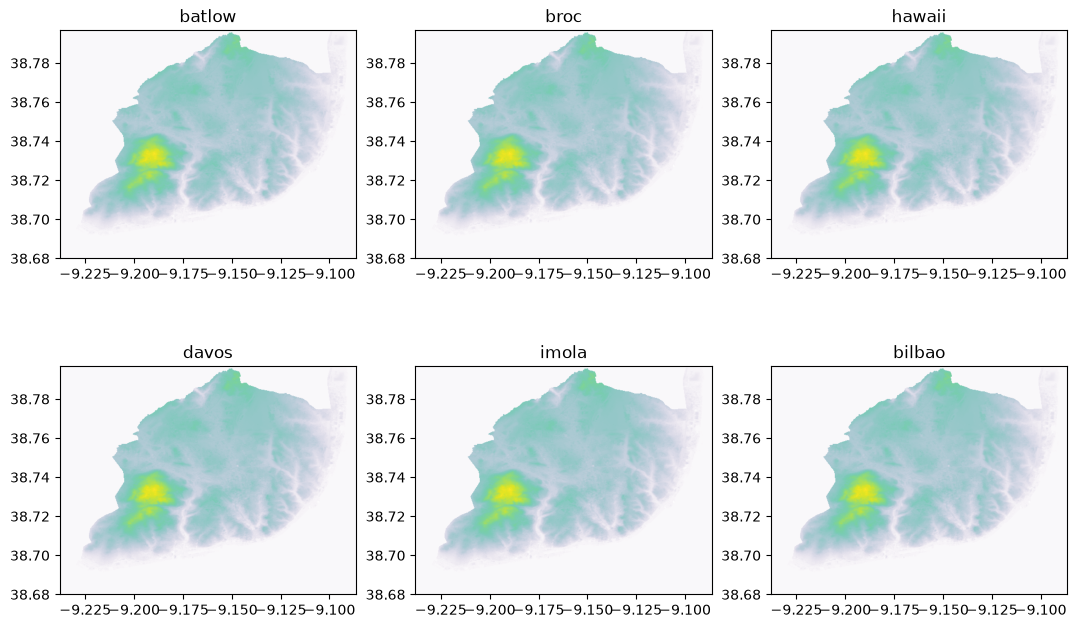

In [3]:
fig, maps = grid(2, 3, crs=dem.epsg, figsize=(13, 8))
for m, name in zip(maps, ['batlow', 'broc', 'hawaii', 'davos', 'imola', 'bilbao']):
    m.imshow(dem, style=name); m.set_title(name)
fig;

## Build your own colormap

`make_diverging(low, high)` and `perceptual_colormap(name, anchors)` return ready-to-use `LinearSegmentedColormap`s - pass them straight to `cmap=`.

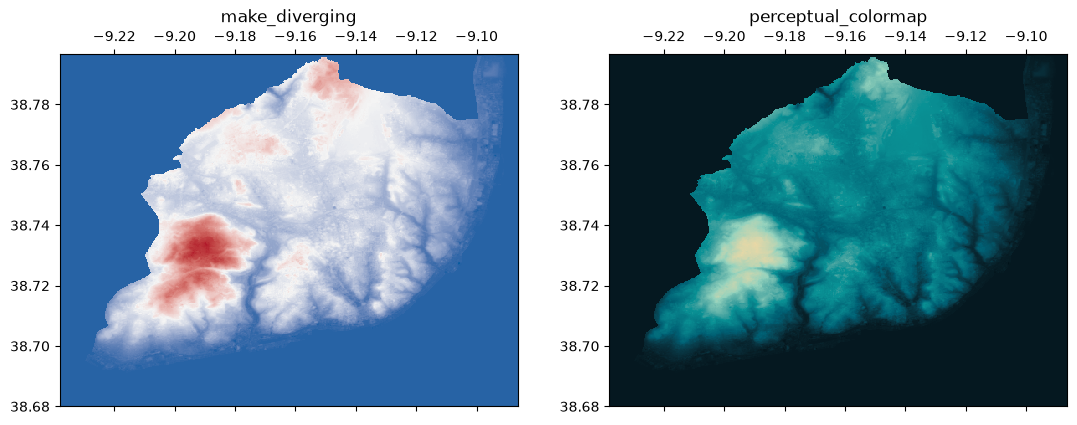

In [4]:
diverging = make_diverging('#2166ac', '#b2182b')
ocean = perceptual_colormap('ocean', ['#001219', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6'])
fig, maps = grid(1, 2, crs=dem.epsg, figsize=(13, 5))
maps[0].imshow(dem, cmap=diverging); maps[0].set_title('make_diverging')
maps[1].imshow(dem, cmap=ocean); maps[1].set_title('perceptual_colormap')
fig;

## Qualitative palettes for categories

The `category*` palettes are qualitative - one distinct colour per class. Coarsen the DEM into elevation zones and draw them as a **categorical** choropleth keyed to a `category12` colormap.

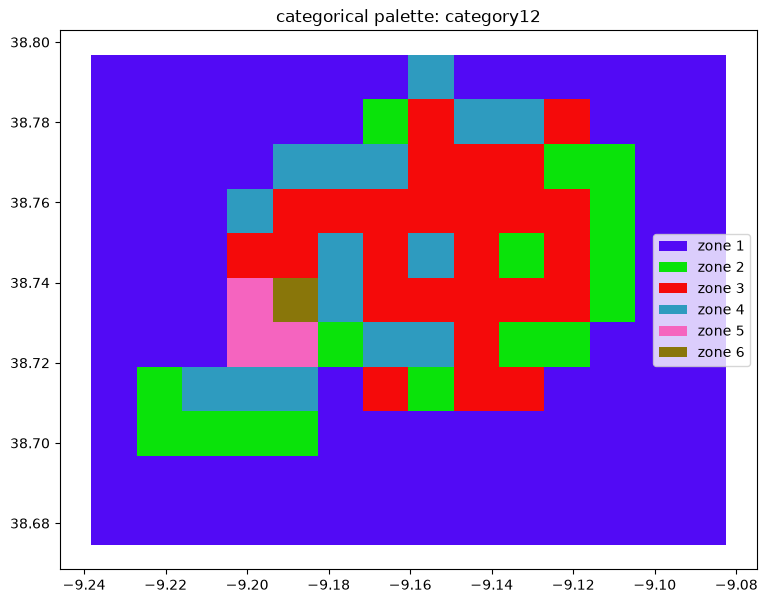

In [5]:
import pandas as pd
coarse = dem.resample(dem.cell_size * 40)
cells = coarse.get_cell_polygons()
elev = coarse.read_array(band=0).astype('float64').ravel()
cells['zone'] = pd.cut(elev, bins=6, labels=['zone %d' % i for i in range(1, 7)]).astype(str)
cmap = ListedColormap(list(get_palette('category12').colors))
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.choropleth(cells, column='zone', scheme='categorical', cmap=cmap)
m.set_title('categorical palette: category12'); m.fig;